#  Model : MLP (Multilayer Perceptron) - Tabular Data
## Dataset : RegresiUTSTelkom.csv

📌 Import Library

In [42]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

📌 Load the dataset

In [44]:
url = '/content/sample_data/RegresiUTSTelkom.csv'  # Update the path if needed
data = pd.read_csv(url)

📌 Check the first few rows of the dataset

In [43]:
print(data.head())

   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0  48.73215  18.42930  70.32679  12.94636 -10.32437 -24.83777   8.76630   
1  50.95714  31.85602  55.81851  13.41693  -6.57898 -18.54940  -3.27872   
2  48.24750  -1.89837  36.29772   2.58776   0.97170 -26.21683   5.05097   
3  50.97020  42.20998  67.09964   8.46791 -15.85279 -16.81409 -12.48207   
4  50.54767   0.31568  92.35066  22.38696 -25.51870 -19.04928  20.67345   

   Feature8  Feature9  Feature10  ...  Feature81  Feature82  Feature83  \
0  -0.92019  18.76548    4.59210  ...    5.66812  -19.68073   33.04964   
1  -2.35035  16.07017    1.39518  ...    3.03800   26.05866  -50.92779   
2 -10.34124   3.55005   -6.36304  ...   34.57337 -171.70734  -16.96705   
3  -9.37636  12.63699    0.93609  ...    9.92661  -55.95724   64.92712   
4  -5.19943   3.63566   -4.69088  ...    6.59753  -50.69577   26.02574   

   Feature84  Feature85  Feature86  Feature87  Feature88  Feature89  Feature90  
0   42.87836   -9.90378

📌 Check for missing values

In [45]:
print(f"Missing values in each column:\n{data.isnull().sum()}")

Missing values in each column:
2001         0
49.94357     0
21.47114     0
73.0775      0
8.74861      0
            ..
-23.08793    1
68.40795     1
-1.82223     1
-27.46348    1
2.26327      1
Length: 91, dtype: int64


 📌 Handle missing values (e.g., drop rows with missing values)

In [46]:
data.dropna(inplace=True)

📌 Set the first row as the column names

In [48]:
data.columns = ['Year', 'Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5',
                'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
                'Feature12', 'Feature13', 'Feature14', 'Feature15', 'Feature16', 'Feature17',
                'Feature18', 'Feature19', 'Feature20', 'Feature21', 'Feature22', 'Feature23',
                'Feature24', 'Feature25', 'Feature26', 'Feature27', 'Feature28', 'Feature29',
                'Feature30', 'Feature31', 'Feature32', 'Feature33', 'Feature34', 'Feature35',
                'Feature36', 'Feature37', 'Feature38', 'Feature39', 'Feature40', 'Feature41',
                'Feature42', 'Feature43', 'Feature44', 'Feature45', 'Feature46', 'Feature47',
                'Feature48', 'Feature49', 'Feature50', 'Feature51', 'Feature52', 'Feature53',
                'Feature54', 'Feature55', 'Feature56', 'Feature57', 'Feature58', 'Feature59',
                'Feature60', 'Feature61', 'Feature62', 'Feature63', 'Feature64', 'Feature65',
                'Feature66', 'Feature67', 'Feature68', 'Feature69', 'Feature70', 'Feature71',
                'Feature72', 'Feature73', 'Feature74', 'Feature75', 'Feature76', 'Feature77',
                'Feature78', 'Feature79', 'Feature80', 'Feature81', 'Feature82', 'Feature83',
                'Feature84', 'Feature85', 'Feature86', 'Feature87', 'Feature88', 'Feature89',
                'Feature90']


📌 Drop the first column (assuming it's an ID or Year)

In [49]:
data = data.drop(columns=['Year'])

📌 Check the first few rows to confirm

In [50]:
print(data.head())

   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0  48.73215  18.42930  70.32679  12.94636 -10.32437 -24.83777   8.76630   
1  50.95714  31.85602  55.81851  13.41693  -6.57898 -18.54940  -3.27872   
2  48.24750  -1.89837  36.29772   2.58776   0.97170 -26.21683   5.05097   
3  50.97020  42.20998  67.09964   8.46791 -15.85279 -16.81409 -12.48207   
4  50.54767   0.31568  92.35066  22.38696 -25.51870 -19.04928  20.67345   

   Feature8  Feature9  Feature10  ...  Feature81  Feature82  Feature83  \
0  -0.92019  18.76548    4.59210  ...    5.66812  -19.68073   33.04964   
1  -2.35035  16.07017    1.39518  ...    3.03800   26.05866  -50.92779   
2 -10.34124   3.55005   -6.36304  ...   34.57337 -171.70734  -16.96705   
3  -9.37636  12.63699    0.93609  ...    9.92661  -55.95724   64.92712   
4  -5.19943   3.63566   -4.69088  ...    6.59753  -50.69577   26.02574   

   Feature84  Feature85  Feature86  Feature87  Feature88  Feature89  Feature90  
0   42.87836   -9.90378

 📌 Define Features and Target

In [51]:
X = data.drop(columns=['Feature90'])  # Drop the target column
y = data['Feature90']  # Assuming Feature90 is the target column

📌 Split the dataset into training and testing sets

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

📌 Feature Scaling

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 📌 Build the MLP Model using TensorFlow/Keras

In [54]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # For regression output (no activation function)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📌 Train the model

In [55]:
history = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 327.6852 - mae: 11.8861 - val_loss: 186.4550 - val_mae: 9.3235
Epoch 2/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 147.7324 - mae: 8.3975 - val_loss: 134.9196 - val_mae: 7.9059
Epoch 3/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 118.6765 - mae: 7.6188 - val_loss: 122.9286 - val_mae: 7.6345
Epoch 4/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 98.8222 - mae: 7.0966 - val_loss: 124.2919 - val_mae: 7.6049
Epoch 5/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 93.6877 - mae: 6.8779 - val_loss: 111.7787 - val_mae: 7.3138
Epoch 6/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 87.5269 - mae: 6.7055 - val_loss: 111.0265 - val_mae: 7.2558
Epoch 7/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 78.2570 - mae: 6.4167 - val_loss: 103.9764 - val_mae: 7.0943
Epoch 8/10
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 76.2550 - mae: 6.3546 - val_loss: 105.0212 - val_mae: 7.1902
Epoch 9/10
1

 📌 Evaluate the model on Test Data

In [56]:
y_pred = model.predict(X_test_scaled)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


📌 Convert predicted values to binary outcomes (classification metrics)

In [58]:
y_pred_class = (y_pred > 0.5).astype(int)  # Convert continuous values to binary based on threshold 0.5

 📌 Evaluate Regression Metrics

In [57]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-Squared: {r_squared}")

Mean Squared Error (MSE): 110.37947099210108
Root Mean Squared Error (RMSE): 10.50616347636477
R-Squared: 0.7858912117462871


 📌 Visualize Predicted vs Actual values

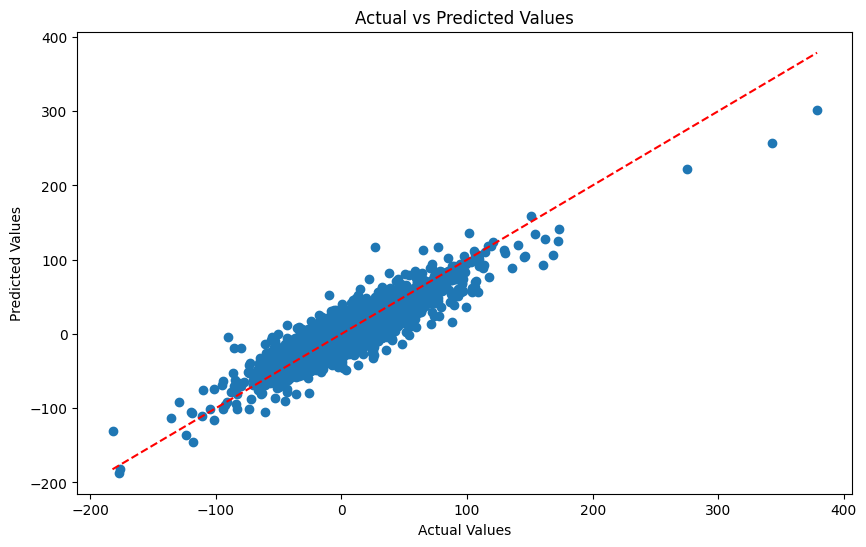

In [59]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()


📌 Visualize Model Loss during Training

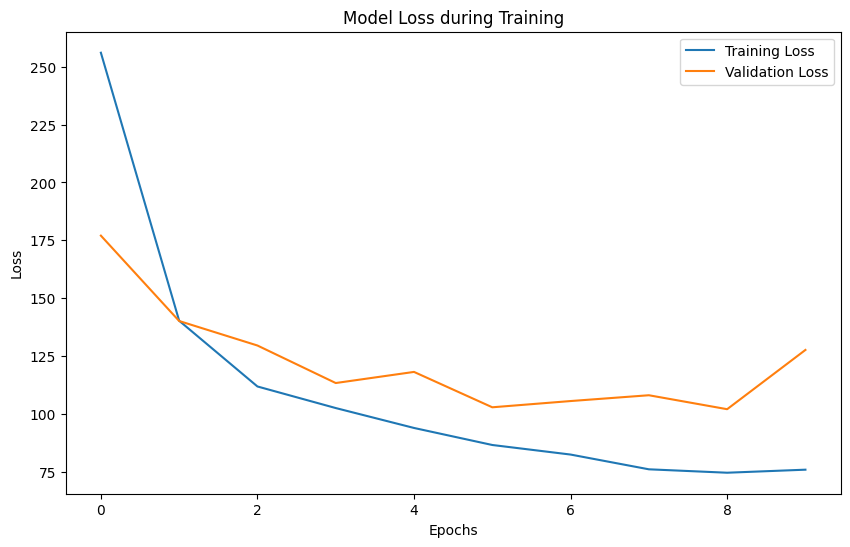

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


📌 Convert

In [32]:
# Step 1: Convert actual target values (y_test) to binary (if they are continuous)
y_test_class = (y_test > 0.5).astype(int)  # Convert to binary based on threshold 0.5

# Step 2: Convert predicted probabilities to binary predictions
y_pred_class = (y_pred > 0.5).astype(int)  # Convert continuous values to binary based on threshold 0.5


📌 Evaluate Classification Metrics

In [62]:
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
roc_auc = roc_auc_score(y_test_class, y_pred_class)

# AUC-ROC: Calculate AUC-ROC based on predicted probabilities (not binary)
roc_auc = roc_auc_score(y_test_class, y_pred)  # Using y_pred which contains the continuous probabilities

print("\n" + "="*50)
print("          Classification Metrics".center(50))
print("="*50)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("="*50)




                   Classification Metrics         
Accuracy     : 0.8141
Precision    : 0.8147
Recall       : 0.8003
F1-Score     : 0.8074
ROC-AUC      : 0.8921


📌 Visualize AUC-ROC

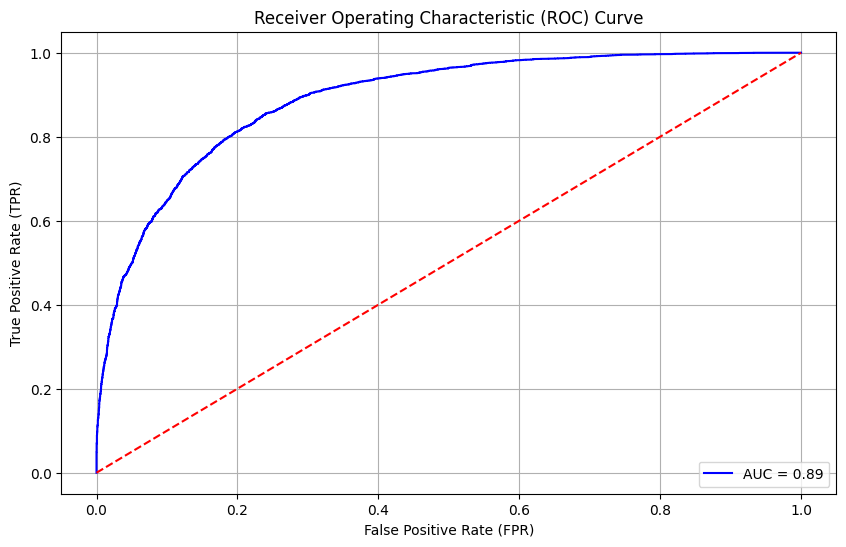

In [41]:
# AUC-ROC: Calculate AUC-ROC based on predicted probabilities (not binary)
roc_auc = roc_auc_score(y_test_class, y_pred)
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_class, y_pred)  # y_pred contains continuous probabilities

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random classifier)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

 📌 Confusion Matrix

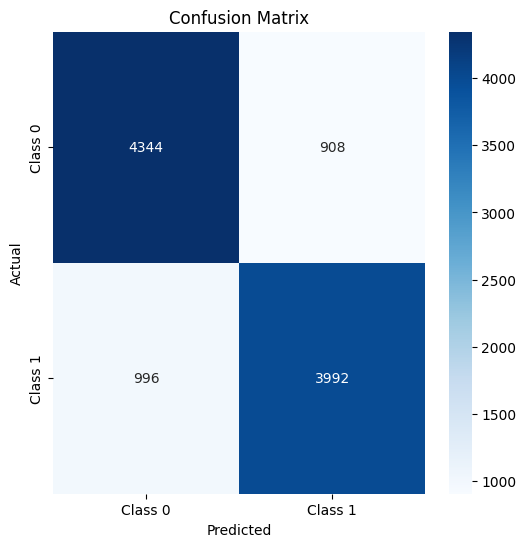

In [63]:
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()